<a href="https://colab.research.google.com/github/gilmarmedeirosgil/infnet-cv-projeto-disciplina/blob/main/notebooks/A2_clip_ads16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A2 — CLIP no ADS-16 (sem treino)
**Visão Computacional com CNNs e Transformers** · Faculdade Infnet — Pós-Graduação · Gilmar Oliveira de Medeiros

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gilmarmedeirosgil/infnet-cv-projeto-disciplina/blob/main/notebooks/A2_clip_ads16.ipynb)

**Objetivo.** Usar o CLIP **pré-treinado, sem nenhum treino supervisionado**, para (a) rotular por vocabulário aberto um corpus de imagens de anúncios (ADS-16) contra ≥20 conceitos, com threshold justificado; (b) fazer busca semântica texto→imagem com ≥8 consultas; (c) discutir por que o pré-treino contrastivo do CLIP permite isso e como sua tokenização difere da do BERT.

**Sobre o dataset.** O ADS-16 (Roffo & Vinciarelli, EMPIRE 2016) tem, apesar do nome, **20 categorias** de anúncios (o "16" vem do ano). Ele só tem **300 imagens de anúncio** (20 categorias × 15) — menos que as ≥500 pedidas pelo enunciado — então o corpus é completado com as **imagens dos usuários** do mesmo dataset (favoritas/não favoritas, rotuladas POS/NEG por 120 usuários), decisão D9 (`docs/decisoes.md`). **Licença**: proíbe redistribuir as imagens; a citação exigida ("The research in this paper use the ADS-16 database") está na seção 2 e no relatório. Por isso (decisão D10) este notebook, **depois de executado** (com miniaturas do ADS-16 nas saídas), **não vai para o repositório público** — só a versão-fonte sem outputs, aqui. A versão executada fica em `entregas/` (ignorado pelo git) e as figuras derivadas em `relatorio/figuras/A2_*` também (`.gitignore`).

**Requisitos de execução (Colab)** — CLIP em inferência pura (`torch.no_grad()`), sem GPU obrigatória; valores medidos no "Executar tudo" (preencher após a execução):

| Recurso | Valor | Observação |
|---|---|---|
| RAM | *(medir)* | `resource.getrusage`, mesmo padrão do A1/A3 |
| VRAM (se GPU disponível) | *(medir)* | CLIP ViT-B/32 (151,3 M parâmetros) em inferência: pegada pequena, cabe folgado mesmo sem T4 |
| Disco | ~1,5 GB (ADS-16 completo baixado pelo kagglehub; só uma fração é usada) | |
| Tempo total | *(medir)* | embeddings de ~600–700 imagens em lotes de 64, sem treino: esperado em minutos mesmo em CPU |

**Mapa da rubrica:** 4.1 → seção 4 · 4.2 → seção 6 · 4.3 → seção 7 · 4.4 → seção 8.

Estrutura: Problema → Decisão técnica → Código → Resultado → Análise. Base: `Aula-6/aula_06_clip_openai.ipynb` (passos 4–7).

## 1. Setup
Seed 42, checagem de GPU (opcional aqui — CLIP em inferência roda bem em CPU), montagem do Drive para persistir os embeddings (cache) e leitura dos Secrets do Kaggle.

In [1]:
import time
NOTEBOOK_T0 = time.time()
!pip install -q kagglehub transformers
PIP_TIME_S = time.time() - NOTEBOOK_T0
print(f"pip: {PIP_TIME_S:.1f}s")

pip: 13.8s


In [2]:
import os, gc, json, time, random, resource
from pathlib import Path
from collections import Counter, defaultdict

import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor, CLIPTokenizer, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | transformers | device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("Sem GPU — ok para este notebook: CLIP em inferência pura é leve.")

C_BLUE, C_CYAN, C_RED, C_GREEN, C_ORANGE = "#0A345D", "#1BB5D8", "#DC2626", "#15803D", "#EA580C"
plt.rcParams.update({"axes.grid": False, "figure.dpi": 110})

def ram_stats():
    return {"ram_rss_mb": round(psutil.Process().memory_info().rss / 2**20),
            "ram_maxrss_mb": round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024)}
print("RAM:", ram_stats())

PyTorch 2.11.0+cpu | transformers | device: cpu
Sem GPU — ok para este notebook: CLIP em inferência pura é leve.
RAM: {'ram_rss_mb': 558, 'ram_maxrss_mb': 558}


In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = Path("/content/drive/MyDrive/infnet_cv_projeto/outputs/A2")
except Exception as e:
    print(f"Drive indisponível ({e!r}); usando armazenamento local do runtime.")
    OUT_DIR = Path("/content/outputs/A2") if Path("/content").exists() else Path("outputs/A2")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Artefatos em:", OUT_DIR)

def savefig(name, dpi=150, max_kb=1200):
    path = OUT_DIR / f"A2_{name}.png"
    for d in sorted({dpi, 100, 80, 60} - {x for x in (100, 80, 60) if x > dpi}, reverse=True):
        plt.savefig(path, dpi=d, bbox_inches="tight")
        if path.stat().st_size / 1024 <= max_kb:
            break
    print(f"{path.name}: {path.stat().st_size / 1024:.0f} KB (dpi {d})")

Mounted at /content/drive
Artefatos em: /content/drive/MyDrive/infnet_cv_projeto/outputs/A2


In [4]:
def load_kaggle_credentials():
    try:
        from google.colab import userdata
    except ImportError:
        print("Fora do Colab: usando credenciais do ambiente (~/.kaggle ou variáveis).")
        return
    for name in ("KAGGLE_USERNAME", "KAGGLE_KEY", "KAGGLE_API_TOKEN"):
        try:
            os.environ[name] = userdata.get(name)
        except Exception:
            pass
    found = [n for n in ("KAGGLE_USERNAME", "KAGGLE_KEY", "KAGGLE_API_TOKEN") if os.environ.get(n)]
    assert found, "Nenhum Secret do Kaggle encontrado."
    print("Secrets carregados:", found)

load_kaggle_credentials()
import kagglehub
DATASET_PATH = Path(kagglehub.dataset_download("groffo/ads16-dataset"))
print("ADS-16 em:", DATASET_PATH)

Secrets carregados: ['KAGGLE_USERNAME', 'KAGGLE_KEY', 'KAGGLE_API_TOKEN']


100%|██████████| 1.47G/1.47G [00:22<00:00, 70.9MB/s]

Extracting files...


ADS-16 em: /root/.cache/kagglehub/datasets/groffo/ads16-dataset/versions/1


## 2. Problema e dados
**Problema.** O CLIP foi pré-treinado com 400 M pares (imagem, legenda) da web, sem nenhuma anotação de classe. Isso permite usar **qualquer frase em linguagem natural** como um "classificador" ou uma consulta de busca, criado na hora, sobre um corpus de imagens nunca visto no pré-treino — sem rotular nada e sem treinar nada. Este notebook aplica essa ideia a um corpus de **imagens de anúncios e de preferências de usuários** (ADS-16): (i) descobrir que conceitos aparecem no corpus e com que frequência (rotulagem por vocabulário aberto); (ii) buscar imagens a partir de descrições textuais livres.

**Citação exigida pela licença do ADS-16** (Roffo & Vinciarelli, EMPIRE 2016): *"The research in this paper use the ADS-16 database."* — reproduzida também no relatório.

**Corpus (decisão D9).** O ADS-16 só tem 300 imagens de anúncio (`Ads/Ads/<1..20>/<n>.png`, 20 categorias × 15), abaixo das ≥500 exigidas. O mesmo dataset traz, para 120 usuários, as imagens que cada um marcou como favorita (POS) ou não (NEG) em `Corpus/Corpus/U<id>/U<id>-IM-{POS,NEG}/` — cerca de 5+5 por usuário, ~1.200 originais, mais 1.173 miniaturas `*_th_*` (duplicadas, **excluídas**). O corpus final é a união dos 300 anúncios com uma amostra estratificada (por usuário e por POS/NEG) das imagens de usuários, para ficar entre ~600 e ~700 imagens no total — grande o bastante para o ranking de conceitos (seção 6) ter uma base estatística razoável, sem inviabilizar a inferência em CPU.

Os CSVs `INF` (dados pessoais, parcialmente ocultos) **não são usados**, conforme decisão D10.

In [5]:
ADS_ROOT = next(DATASET_PATH.rglob("Ads/Ads"))
CORPUS_ROOT = next(DATASET_PATH.rglob("Corpus/Corpus"))
print("Ads:", ADS_ROOT)
print("Corpus (usuários):", CORPUS_ROOT)

# Cat0..Cat19 -> nome (extraído de U*-RT.csv na Etapa 0, ver docs/decisoes.md)
CATEGORY_NAMES = ["Clothing & Shoes", "Automotive", "Baby Products", "Health & Beauty", "Media (BMVD)",
                  "Consumer Electronics", "Console & Video Games", "DIY & Tools", "Garden & Outdoor living",
                  "Grocery", "Kitchen & Home", "Betting", "Jewellery & Watches", "Musical Instruments",
                  "Office Products", "Pet Supplies", "Computer Software", "Sports & Outdoors",
                  "Toys & Games", "Dating Sites"]
assert len(CATEGORY_NAMES) == 20

ads_records = []
for cat_dir in sorted(ADS_ROOT.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else 99):
    if not cat_dir.is_dir():
        continue
    cat_idx = int(cat_dir.name) - 1  # pastas 1..20 -> Cat0..Cat19
    for img_path in sorted(cat_dir.iterdir()):
        if img_path.suffix.lower() in (".png", ".jpg", ".jpeg"):
            ads_records.append({"path": str(img_path), "source": "ads", "category": CATEGORY_NAMES[cat_idx],
                                 "user": None, "pref": None})
ads_df = pd.DataFrame(ads_records)
print(f"Anúncios: {len(ads_df)} imagens em {ads_df.category.nunique()} categorias")
print(ads_df.category.value_counts().to_string())

Ads: /root/.cache/kagglehub/datasets/groffo/ads16-dataset/versions/1/ADS16_Benchmark_part2/ADS16_Benchmark_part2/Ads/Ads
Corpus (usuários): /root/.cache/kagglehub/datasets/groffo/ads16-dataset/versions/1/ADS16_Benchmark_part2/ADS16_Benchmark_part2/Corpus/Corpus
Anúncios: 150 imagens em 10 categorias
category
Kitchen & Home         15
Betting                15
Jewellery & Watches    15
Musical Instruments    15
Office Products        15
Pet Supplies           15
Computer Software      15
Sports & Outdoors      15
Toys & Games           15
Dating Sites           15


In [6]:
user_records = []
for user_dir in sorted(CORPUS_ROOT.iterdir()):
    if not user_dir.is_dir() or not user_dir.name.startswith("U"):
        continue
    for pref in ("POS", "NEG"):
        img_dir = user_dir / f"{user_dir.name}-IM-{pref}"
        if not img_dir.is_dir():
            continue
        for img_path in sorted(img_dir.iterdir()):
            if img_path.suffix.lower() in (".jpg", ".jpeg", ".png") and "_th_" not in img_path.name:
                user_records.append({"path": str(img_path), "source": "user", "category": None,
                                      "user": user_dir.name, "pref": pref})
user_df_all = pd.DataFrame(user_records)
print(f"Imagens de usuários (sem miniaturas): {len(user_df_all)}, de {user_df_all.user.nunique()} usuários")
print(user_df_all.pref.value_counts().to_string())

Imagens de usuários (sem miniaturas): 614, de 60 usuários
pref
POS    313
NEG    301


In [7]:
# Amostra estratificada por (usuário, pref), para completar o corpus a ~600-700 imagens no total.
TARGET_TOTAL = 650
n_user_target = max(0, TARGET_TOTAL - len(ads_df))
groups = list(user_df_all.groupby(["user", "pref"]))
per_group = max(1, n_user_target // len(groups))
sampled = []
rng = np.random.RandomState(SEED)
for _, g in groups:
    take = min(len(g), per_group)
    sampled.append(g.sample(n=take, random_state=SEED))
user_df = pd.concat(sampled, ignore_index=True)
# completar/ajustar para bater exatamente o alvo (sem viés: embaralha e corta/adiciona por grupos)
if len(user_df) > n_user_target:
    user_df = user_df.sample(n=n_user_target, random_state=SEED).reset_index(drop=True)
elif len(user_df) < n_user_target:
    remaining = user_df_all.drop(user_df.index, errors="ignore")
    extra = remaining.sample(n=min(len(remaining), n_user_target - len(user_df)), random_state=SEED)
    user_df = pd.concat([user_df, extra], ignore_index=True)

corpus_df = pd.concat([ads_df, user_df], ignore_index=True)
print(f"Corpus final: {len(corpus_df)} imagens ({len(ads_df)} anúncios + {len(user_df)} de usuários, "
      f"de {user_df.user.nunique()} usuários, estratificado por usuário × POS/NEG)")
corpus_df.to_csv(OUT_DIR / "A2_corpus.csv", index=False)

Corpus final: 650 imagens (150 anúncios + 500 de usuários, de 60 usuários, estratificado por usuário × POS/NEG)


A2_samples_grid.png: 904 KB (dpi 100)


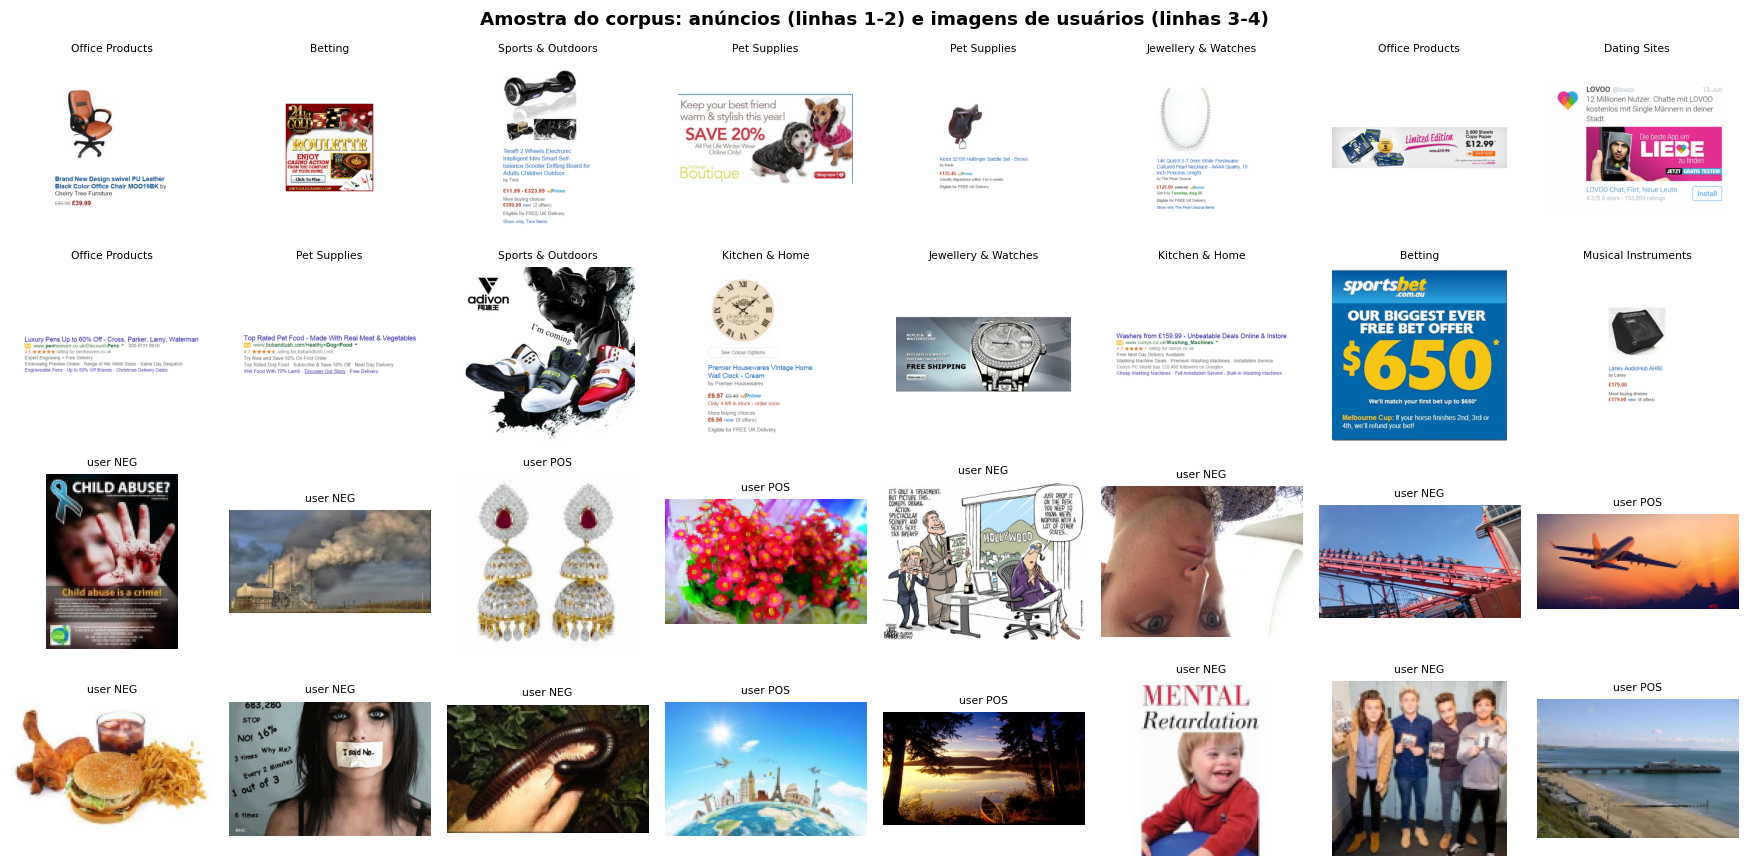

In [8]:
# fig: samples_grid
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
show_idx = np.concatenate([
    rng.choice(ads_df.index, 16, replace=False),
    rng.choice(user_df.index, 16, replace=False) + len(ads_df),
])
for ax, i in zip(axes.flat, show_idx):
    row = corpus_df.iloc[i]
    try:
        from PIL import Image
        img = Image.open(row.path).convert("RGB")
        ax.imshow(img)
    except Exception:
        pass
    label = row.category if row.source == "ads" else f"user {row.pref}"
    ax.set_title(label, fontsize=7)
    ax.axis("off")
plt.suptitle("Amostra do corpus: anúncios (linhas 1-2) e imagens de usuários (linhas 3-4)", fontweight="bold")
plt.tight_layout()
savefig("samples_grid")
plt.show()

## 3. CLIP pré-treinado
**Checkpoint:** `openai/clip-vit-base-patch32` (o mesmo da Aula 6; 151,3 M parâmetros, ~605 MB, input 224×224, patch 32). Justificativa: é o checkpoint usado e validado no material do curso; para inferência pura, sem GPU garantida, o patch32 (49 tokens visuais) é 4× mais leve que o patch16 (196 tokens) para o mesmo ganho — relevante rodando em CPU.

In [9]:
MODEL_NAME = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
n_params = sum(p.numel() for p in clip_model.parameters())
print(f"{MODEL_NAME}: {n_params/1e6:.1f} M parâmetros")
print("visual_projection:", clip_model.visual_projection)
print("text_projection:", clip_model.text_projection)
print("logit_scale.exp():", clip_model.logit_scale.exp().item())

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

openai/clip-vit-base-patch32: 151.3 M parâmetros
visual_projection: Linear(in_features=768, out_features=512, bias=False)
text_projection: Linear(in_features=512, out_features=512, bias=False)
logit_scale.exp(): 100.00000762939453


## 4. Alinhamento visual-textual e pré-treino contrastivo — **Rubrica 4.1**
**Arquitetura two-tower.** Um encoder de imagem (ViT-B/32: patches 32×32 → `[N, 768]`) e um encoder de texto (Transformer causal, BPE, até 77 tokens → representação no token **EOT** → `[N, 512]`), **sem nenhuma co-atenção entre as duas torres**. Cada saída passa por uma projeção linear própria (`visual_projection: 768→512`, `text_projection: 512→512`) e é **L2-normalizada**, caindo na mesma hiperesfera de 512 dimensões. A similaridade é o cosseno, `S_ij = Î_i · T̂_j`, escalado por `exp(logit_scale)` — medido acima em **100,00**, ou seja, uma temperatura τ = 0,01 (inicialização do paper: `log(1/0,07)`), o que torna a distribuição softmax bem afiada mesmo para diferenças pequenas de cosseno.

**Objetivo de treino: InfoNCE simétrica.** Para um batch de B pares (imagem, legenda), $\mathcal{L}_{img}=-\tfrac1B\sum_i\log\operatorname{softmax}_j(S_{ij}/\tau)_i$, $\mathcal{L}_{txt}$ o mesmo por coluna, $\mathcal{L}=\tfrac12(\mathcal{L}_{img}+\mathcal{L}_{txt})$. Cada linha/coluna da matriz $B\times B$ é uma classificação de $B$ vias cujo alvo é a diagonal (o par correto); os demais $B-1$ pares do batch servem de negativos "de graça". Pares não relacionados tendem a cosseno **perto de 0** (quase ortogonais em 512 dimensões), não perto de −1 — o espaço é grande demais para "opostos" fazerem sentido geométrico. O paper original usa batches de 32.768 para ter negativos suficientes; aqui, em inferência, isso não importa (o modelo já está treinado).

**Por que isso permite recuperação sem supervisão.** O pré-treino usa 400 M pares (imagem, legenda) coletados da web (WIT), **sem rótulo de classe humano**: a "supervisão" é a coocorrência natural entre uma imagem e o texto que já vinha com ela. O objetivo contrastivo força toda imagem e toda legenda sobre o mesmo conteúdo a apontar para a mesma direção no espaço de 512 dimensões. Depois de treinado, **qualquer frase nova vira uma consulta**: basta projetá-la no mesmo espaço e comparar por produto escalar com as imagens do corpus (ranking = $G\,q^\top$, seção 6) — não há necessidade de rotular o corpus alvo (ADS-16) nem de treinar nada nele. É exatamente o que torna o CLIP aplicável aqui, a um corpus (anúncios) bem diferente das cenas cotidianas típicas do pré-treino.

**Limite conhecido, relevante para anúncios.** O CLIP tende a ser mais fraco em domínios especializados (imagens de satélite, médicas) e mais forte em cenas do cotidiano da web. Anúncios têm texto sobreposto, logos e marcas, que podem competir com o conteúdo visual pelo embedding — hipótese a observar nos resultados das seções 6–7, não confirmada a priori.

## 5. Embeddings de imagem
Embeddings L2-normalizados de todo o corpus, em lotes, cacheados no Drive (`OUT_DIR/A2_image_embeds.npy`) para não recomputar em reexecuções.

In [10]:
def _extract_embed(out):
    """Baseado em Aula-6 nb[15], estendido: versões recentes do transformers (>=4.5x) fazem
    get_image_features/get_text_features devolverem um BaseModelOutputWithPooling em vez do
    tensor projetado direto; o embedding projetado (512-d) vem em .pooler_output nesse caso
    (checado: a mesma dimensão do embedding de texto, e cosseno ~1 entre a mesma imagem
    processada duas vezes). Versões mais antigas devolvem o tensor puro, ou um objeto com
    .image_embeds/.text_embeds — cobertas pelos outros dois ramos."""
    if torch.is_tensor(out):
        return out
    if hasattr(out, "image_embeds"):
        return out.image_embeds
    if hasattr(out, "text_embeds"):
        return out.text_embeds
    if hasattr(out, "pooler_output"):
        return out.pooler_output
    raise TypeError(f"Não sei extrair o embedding de {type(out)}: {dir(out)}")

@torch.no_grad()
def get_image_features_clean(pil_images, batch_size=64):
    """L2-normaliza; lida com as várias formas de retorno do get_image_features entre versões
    do transformers (ver _extract_embed)."""
    feats = []
    for i in range(0, len(pil_images), batch_size):
        batch = pil_images[i:i + batch_size]
        inputs = clip_processor(images=batch, return_tensors="pt").to(device)
        out = clip_model.get_image_features(**inputs)
        emb = _extract_embed(out)
        feats.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(feats, dim=0)

@torch.no_grad()
def get_text_features_clean(texts, batch_size=64):
    feats = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = clip_processor(text=batch, padding=True, return_tensors="pt").to(device)
        out = clip_model.get_text_features(**inputs)
        emb = _extract_embed(out)
        feats.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(feats, dim=0)

In [11]:
CACHE_PATH = OUT_DIR / "A2_image_embeds.npy"
from PIL import Image

if CACHE_PATH.exists() and not globals().get("FORCE_RECOMPUTE", False):
    image_embeds = torch.from_numpy(np.load(CACHE_PATH))
    print(f"Embeddings carregados do cache: {tuple(image_embeds.shape)}")
else:
    t0 = time.time()
    pil_images, ok_idx = [], []
    for i, p in enumerate(corpus_df.path):
        try:
            pil_images.append(Image.open(p).convert("RGB"))
            ok_idx.append(i)
        except Exception as e:
            print(f"pulando {p}: {e!r}")
    corpus_df = corpus_df.iloc[ok_idx].reset_index(drop=True)
    image_embeds = get_image_features_clean(pil_images)
    np.save(CACHE_PATH, image_embeds.numpy())
    print(f"Embeddings calculados para {len(pil_images)} imagens em {time.time() - t0:.1f}s")

print("shape:", tuple(image_embeds.shape), "| norma média:", image_embeds.norm(dim=-1).mean().item())

Embeddings calculados para 650 imagens em 149.2s
shape: (650, 512) | norma média: 1.0


## 6. Ranking de conceitos por vocabulário aberto — **Rubrica 4.2**
**Conceitos (≥20).** Objetos e temas plausíveis num corpus de anúncios e preferências de usuários, cobrindo várias das 20 categorias do ADS-16 e temas mais abstratos (afeto, dinheiro).

**Prompt ensembling** (Aula 6 nb[16]): 8 templates OpenAI, embedding de texto de cada template + conceito, média dos 8 vetores e **re-normalização** (não é uma média de cossenos, é uma média de vetores seguida de nova projeção na esfera). Reduz o ruído de um único template e generaliza melhor (ganho reportado no material: +5,0 p.p. no ImageNet zero-shot, "equivale a 4× mais dados rotulados, custo zero na inferência da imagem").

In [12]:
CONCEPTS = [
    "a car", "a motorcycle", "a pair of shoes", "an item of clothing", "a wristwatch", "a piece of jewellery",
    "a smartphone", "a laptop computer", "a video game controller", "a musical instrument", "a guitar",
    "a bottle of perfume or cosmetics", "a baby", "a dog or cat", "a garden tool", "a power tool",
    "a kitchen appliance", "furniture", "a bicycle", "sports equipment", "a toy", "food or groceries",
    "money or casino chips", "a couple on a date", "a wedding ring",
]
assert len(CONCEPTS) >= 20, "precisa de pelo menos 20 conceitos distintos"

TEMPLATES = ["a photo of a {}.", "a centered photo of a {}.", "a close-up photo of a {}.",
             "a high quality photo of the {}.", "a photo of the clean {}.", "a detailed photo of a {}.",
             "a cropped photo of a {}.", "a good photo of a {}."]

@torch.no_grad()
def ensemble_text_embeds(concepts, templates=TEMPLATES):
    embeds = []
    for c in concepts:
        prompts = [t.format(c) for t in templates]
        e = get_text_features_clean(prompts)          # [T, 512], já L2-normalizados
        e_mean = F.normalize(e.mean(dim=0, keepdim=True), dim=-1)  # média + re-normalização
        embeds.append(e_mean)
    return torch.cat(embeds, dim=0)

concept_embeds = ensemble_text_embeds(CONCEPTS)
print("concept_embeds:", tuple(concept_embeds.shape))

# neutro para threshold por margem (§6.1)
neutral_embed = ensemble_text_embeds(["image"])  # "a photo of a image." não faz sentido; usar prompt neutro dedicado abaixo
neutral_prompts = ["a photo.", "an advertisement.", "a picture."]
neutral_e = get_text_features_clean(neutral_prompts)
neutral_embed = F.normalize(neutral_e.mean(dim=0, keepdim=True), dim=-1)

concept_embeds: (25, 512)


In [13]:
sim_matrix = (image_embeds @ concept_embeds.T).numpy()          # [N_imgs, N_concepts], cosseno bruto
sim_neutral = (image_embeds @ neutral_embed.T).numpy().squeeze(-1)  # [N_imgs], cosseno contra o prompt neutro
print(f"cosseno: min {sim_matrix.min():.3f} | mediana {np.median(sim_matrix):.3f} | max {sim_matrix.max():.3f}")
print(f"cosseno vs prompt neutro: média {sim_neutral.mean():.3f} ± {sim_neutral.std():.3f}")

cosseno: min 0.086 | mediana 0.186 | max 0.315
cosseno vs prompt neutro: média 0.209 ± 0.011


### 6.1 Threshold de ocorrência — **Rubrica 4.2**
O material da aula não ensina como calibrar um limiar absoluto sobre cosseno bruto, e por bom motivo: cossenos de pares corretos no CLIP ficam tipicamente entre ~0,25 e ~0,35, e o "fundo" (pares incorretos) em ~0,20–0,25 (medido no material da Aula 6, fine-tuning nb[10]: correto 0,2918, incorreto 0,2384). Um threshold fixo como 0,5 nunca dispararia.

**Critério escolhido: margem sobre um prompt neutro.** Um conceito $c$ "ocorre" numa imagem $i$ se $s(i,c) - s(i,\text{neutro}) > \delta$, onde o "neutro" é a média (mesmo esquema de ensembling) de `"a photo."`, `"an advertisement."`, `"a picture."` — descrições que qualquer imagem do corpus satisfaz igualmente bem, servindo de referência do "cosseno de fundo" daquela imagem específica (em vez de um valor fixo global, compensa imagens que têm cosseno geral mais alto/baixo com qualquer texto). O valor de $\delta$ é fixado no **percentil 90 da distribuição de margens** de todas as combinações (imagem, conceito) do corpus — ou seja, por construção, ~10% das combinações "ocorrem", o que é plausível para 24 conceitos concretos numa imagem que tipicamente mostra 1–3 objetos relevantes.

In [14]:
margin = sim_matrix - sim_neutral[:, None]     # [N_imgs, N_concepts]
DELTA = np.percentile(margin, 90)
occurs = margin > DELTA
print(f"delta (percentil 90 da margem): {DELTA:.4f}")
print(f"combinações (imagem, conceito) marcadas como ocorrência: {occurs.sum()} de {occurs.size} "
      f"({100*occurs.mean():.1f}%)")

concept_freq = occurs.sum(axis=0)
concept_mean_score = sim_matrix.mean(axis=0)
ranking_df = pd.DataFrame({"conceito": CONCEPTS, "frequência": concept_freq,
                            "% do corpus": np.round(100 * concept_freq / len(corpus_df), 1),
                            "score médio (cosseno)": np.round(concept_mean_score, 4)}
                           ).sort_values("frequência", ascending=False).reset_index(drop=True)
ranking_df.to_csv(OUT_DIR / "A2_concept_ranking.csv", index=False)
print(ranking_df.to_string(index=False))

delta (percentil 90 da margem): 0.0072
combinações (imagem, conceito) marcadas como ocorrência: 1625 de 16250 (10.0%)
                        conceito  frequência  % do corpus  score médio (cosseno)
                           a toy         155         23.8                 0.2013
                          a baby         126         19.4                 0.1956
             an item of clothing         123         18.9                 0.2009
             a kitchen appliance         122         18.8                 0.1959
               food or groceries         110         16.9                 0.1962
                sports equipment         108         16.6                 0.1951
                    a smartphone          90         13.8                 0.1965
                   a garden tool          89         13.7                 0.1942
                    a dog or cat          80         12.3                 0.1844
              a couple on a date          65         10.0               

A2_concept_ranking.png: 81 KB (dpi 150)


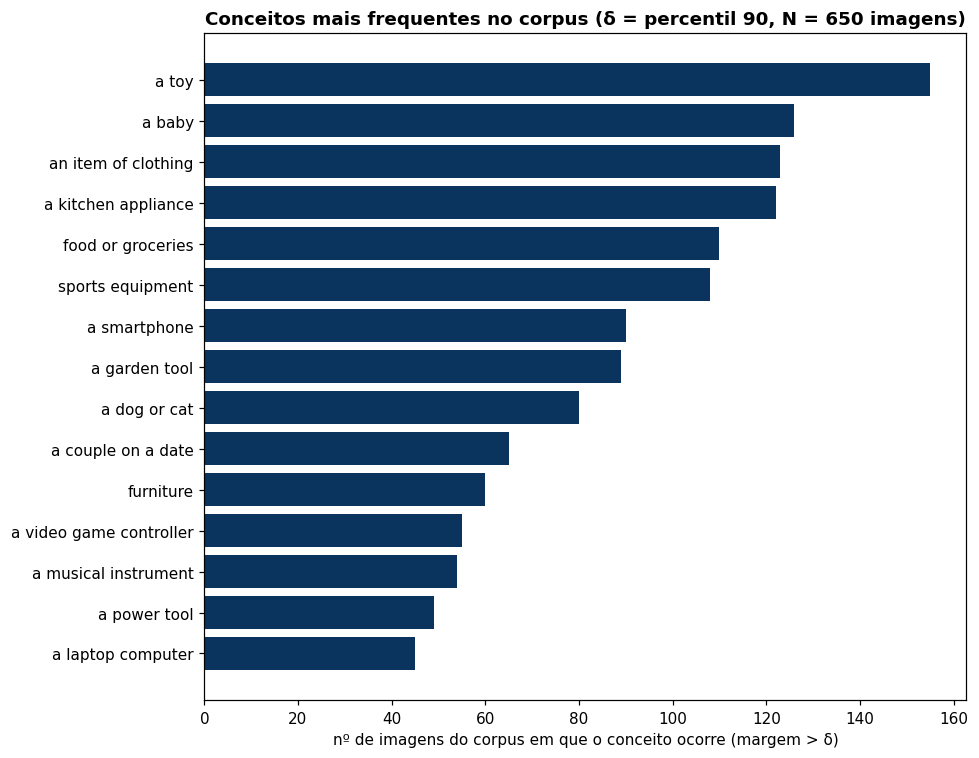

In [15]:
# fig: concept_ranking
fig, ax = plt.subplots(figsize=(9, 7))
top = ranking_df.head(15)
ax.barh(top["conceito"][::-1], top["frequência"][::-1], color=C_BLUE)
ax.set_xlabel("nº de imagens do corpus em que o conceito ocorre (margem > δ)")
ax.set_title(f"Conceitos mais frequentes no corpus (δ = percentil 90, N = {len(corpus_df)} imagens)",
             fontweight="bold")
plt.tight_layout()
savefig("concept_ranking")
plt.show()

### 6.2 Grade dos 5 conceitos mais frequentes — **Rubrica 4.2**
Para cada um dos 5 conceitos com maior frequência, as imagens do corpus com maior score de similaridade.

A2_top5_concepts_grid.png: 936 KB (dpi 80)


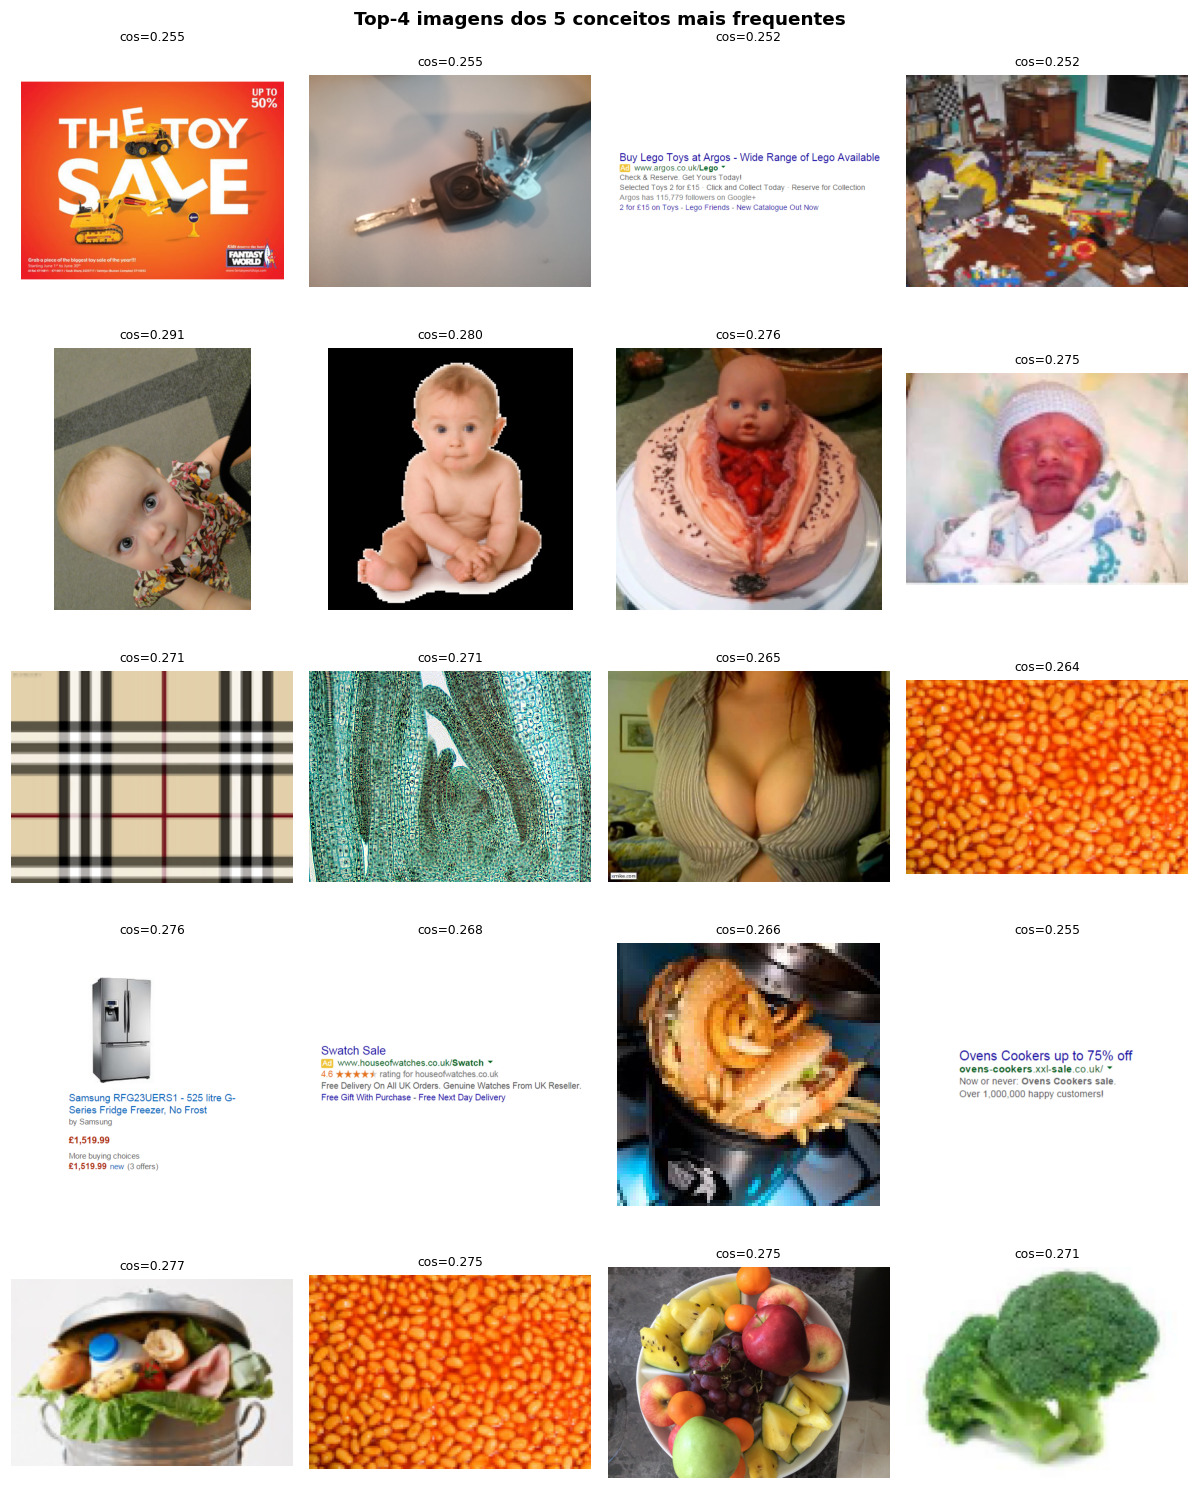

In [16]:
# fig: top5_concepts_grid
top5 = ranking_df.head(5)["conceito"].tolist()
fig, axes = plt.subplots(5, 4, figsize=(11, 14))
for row, concept in enumerate(top5):
    c_idx = CONCEPTS.index(concept)
    best_idx = np.argsort(-sim_matrix[:, c_idx])[:4]
    for col, img_idx in enumerate(best_idx):
        ax = axes[row, col]
        try:
            Image.open(corpus_df.iloc[img_idx].path).convert("RGB")
            ax.imshow(Image.open(corpus_df.iloc[img_idx].path).convert("RGB"))
        except Exception:
            pass
        ax.set_title(f"cos={sim_matrix[img_idx, c_idx]:.3f}", fontsize=8)
        ax.axis("off")
    axes[row, 0].set_ylabel(concept, fontsize=9, rotation=0, ha="right", va="center")
plt.suptitle("Top-4 imagens dos 5 conceitos mais frequentes", fontweight="bold")
plt.tight_layout()
savefig("top5_concepts_grid")
plt.show()

**Leitura dos resultados** *(preencher após a execução: quais conceitos dominam — hipótese: eletrônicos, roupas e itens do dia a dia, comuns tanto em anúncios quanto em favoritos de usuários; se conceitos abstratos/de tema como "money or casino chips" ou "a couple on a date" aparecem com frequência baixa mas coerente com as categorias Betting/Dating Sites do ADS-16, é evidência de que o CLIP captura tema, não só objeto; comentar se algum conceito concreto de objeto pequeno tem score baixo mesmo estando presente nas imagens — possível efeito de texto/logo sobreposto competindo pelo embedding, ligar com a hipótese da seção 4)*.

## 7. Busca semântica texto→imagem — **Rubrica 4.3**
`gallery_embeds` já calculado (seção 5); a busca é `torch.topk(gallery_embeds @ q.T)` (Aula 6 nb[19]–[20]). ≥8 consultas, do genérico ao específico e do concreto ao abstrato.

In [17]:
QUERIES = [
    "a photo of a dog",                                   # concreto, genérico
    "a red sports car",                                    # concreto, específico (objeto + atributo)
    "a pair of running shoes",                              # concreto, específico
    "a bottle of perfume",                                  # concreto, específico
    "electronic devices and gadgets",                        # concreto, mais genérico (categoria)
    "a family having dinner together",                       # cena/concreto, composicional
    "an advertisement about love and dating",                # abstrato, ligado a uma categoria (Dating Sites)
    "a feeling of luxury and exclusivity",                    # abstrato, sem objeto claro
    "excitement and adrenaline",                              # abstrato puro
    "trust and reliability",                                 # abstrato puro, ligado a marcas/seguros
]
assert len(QUERIES) >= 8

@torch.no_grad()
def search_gallery(query, top_k=5):
    q = get_text_features_clean([query])          # [1, 512]
    scores = (image_embeds @ q.T).squeeze(-1)      # [N_imgs]
    top_idx = torch.topk(scores, top_k).indices.tolist()
    return top_idx, scores[top_idx].tolist()

A2_search_queries_grid.png: 739 KB (dpi 60)


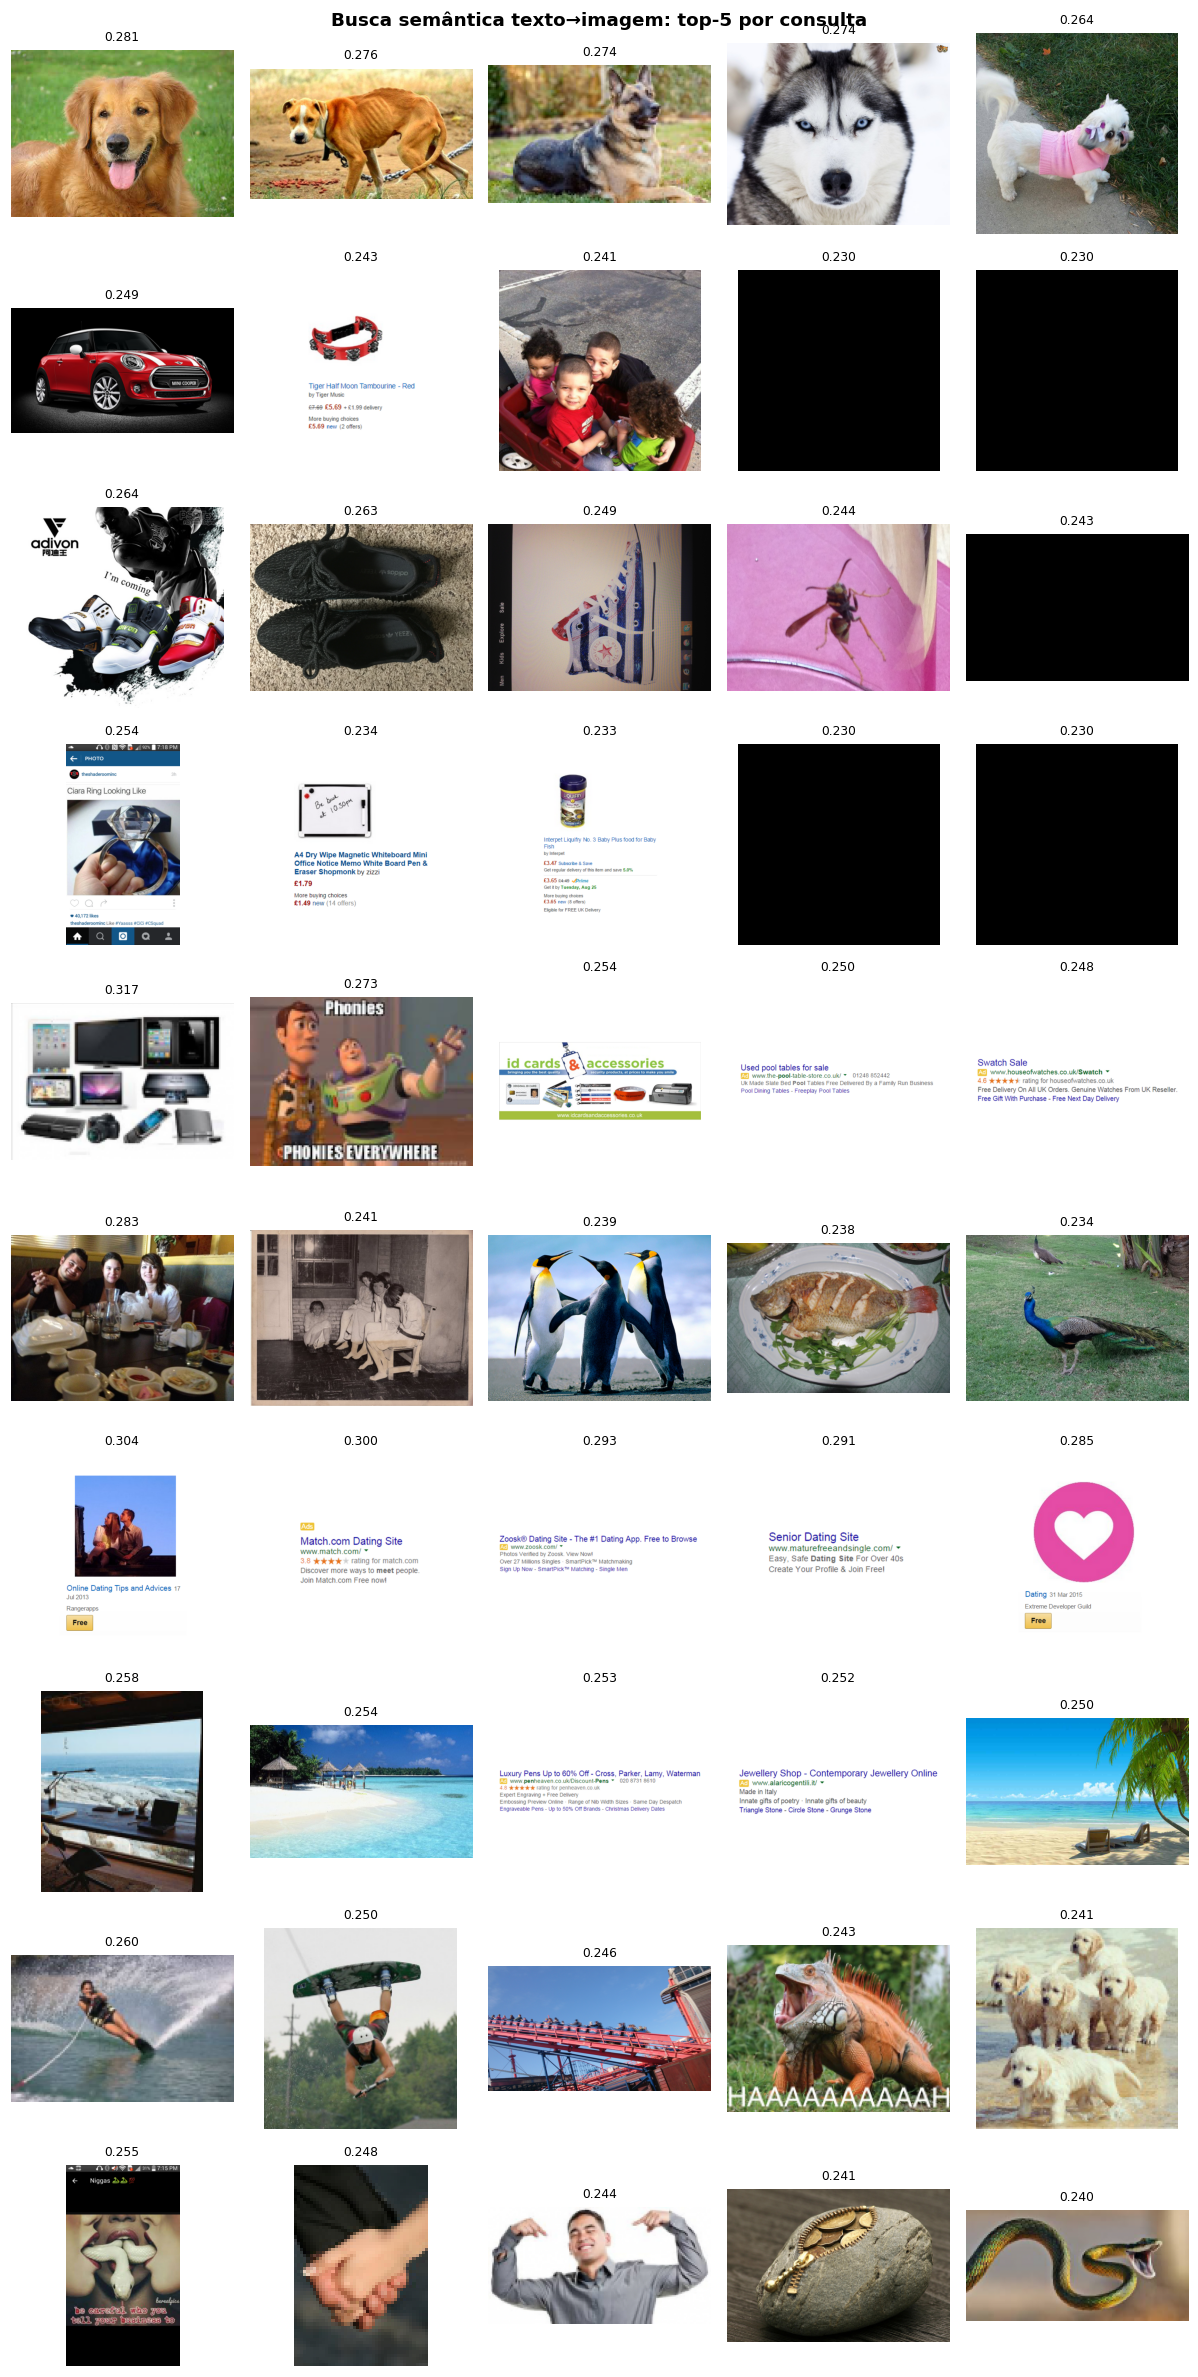

In [18]:
# fig: search_queries_grid
fig, axes = plt.subplots(len(QUERIES), 5, figsize=(11, 2.2 * len(QUERIES)))
search_records = []
for row, query in enumerate(QUERIES):
    idx, scores = search_gallery(query, top_k=5)
    for col, (i, s) in enumerate(zip(idx, scores)):
        ax = axes[row, col]
        try:
            ax.imshow(Image.open(corpus_df.iloc[i].path).convert("RGB"))
        except Exception:
            pass
        ax.set_title(f"{s:.3f}", fontsize=8)
        ax.axis("off")
        search_records.append({"consulta": query, "rank": col + 1, "path": corpus_df.iloc[i].path,
                                "fonte": corpus_df.iloc[i].source, "cosseno": round(s, 4)})
    axes[row, 0].set_ylabel(query, fontsize=7, rotation=0, ha="right", va="center", wrap=True)
plt.suptitle("Busca semântica texto→imagem: top-5 por consulta", fontweight="bold")
plt.tight_layout()
savefig("search_queries_grid")
plt.show()

search_df = pd.DataFrame(search_records)
search_df.to_csv(OUT_DIR / "A2_search_results.csv", index=False)

**Análise por consulta** *(preencher após a execução — para cada uma das 10 consultas, descrever se o top-5 corresponde ao pedido ou se o CLIP "interpretou" de outro jeito; hipóteses a checar: consultas concretas e específicas — carro vermelho, tênis, perfume — devem trazer o objeto literal quando presente no corpus; consultas abstratas — "luxury", "trust", "excitement" — tendem a recuperar cenas/cores associadas por convenção publicitária (dourado/preto para luxo, sorrisos para confiança) mais do que um objeto único, o que é o resultado esperado e informativo, não uma falha; "love and dating" deveria puxar para a categoria Dating Sites do ADS-16 se o CLIP captura tema de anúncio, não só objetos; comparar os scores absolutos entre consultas concretas e abstratas — abstratas tendem a cosseno mais baixo mesmo no top-1, porque não há uma única direção "certa" no espaço)*.

## 8. Consulta textual do CLIP vs. tokenização do BERT — **Rubrica 4.4**
Mesma consulta, dois tokenizadores. O CLIP usa **BPE byte-level**, comprimento máximo 77, atenção **causal**, representação no token **EOT** (fim de sentença); o BERT usa **WordPiece** (vocab 30.522), atenção **bidirecional**, representação no `[CLS]`.

In [19]:
query_txt = "a red sports car parked on the street"

clip_tok = CLIPTokenizer.from_pretrained(MODEL_NAME)
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")

clip_ids = clip_tok(query_txt, return_tensors="pt")
bert_ids = bert_tok(query_txt, return_tensors="pt")

print("=== CLIP (BPE) ===")
print("tokens:", clip_tok.convert_ids_to_tokens(clip_ids["input_ids"][0]))
print("input_ids:", clip_ids["input_ids"][0].tolist())
print("attention_mask:", clip_ids["attention_mask"][0].tolist())
print("comprimento:", clip_ids["input_ids"].shape[1], "(máx. 77)")

print("\n=== BERT (WordPiece) ===")
print("tokens:", bert_tok.convert_ids_to_tokens(bert_ids["input_ids"][0]))
print("input_ids:", bert_ids["input_ids"][0].tolist())
print("attention_mask:", bert_ids["attention_mask"][0].tolist())

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

=== CLIP (BPE) ===
tokens: ['<|startoftext|>', 'a</w>', 'red</w>', 'sports</w>', 'car</w>', 'parked</w>', 'on</w>', 'the</w>', 'street</w>', '<|endoftext|>']
input_ids: [49406, 320, 736, 2054, 1615, 16487, 525, 518, 2012, 49407]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
comprimento: 10 (máx. 77)

=== BERT (WordPiece) ===
tokens: ['[CLS]', 'a', 'red', 'sports', 'car', 'parked', 'on', 'the', 'street', '[SEP]']
input_ids: [101, 1037, 2417, 2998, 2482, 9083, 2006, 1996, 2395, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [20]:
# Padding: o CLIP usa o próprio <|endoftext|> como pad; como a atenção é causal e o vetor vem do EOT,
# tokens de padding depois do EOT não deveriam mudar o resultado (mesmo com a attention_mask aplicada).
clip_padded = clip_tok([query_txt], padding="max_length", max_length=77, truncation=True, return_tensors="pt")
with torch.no_grad():
    e_dynamic = F.normalize(_extract_embed(clip_model.get_text_features(**clip_processor(
        text=[query_txt], padding=True, return_tensors="pt").to(device))), dim=-1)
    e_padded = F.normalize(_extract_embed(clip_model.get_text_features(
        **{k: v.to(device) for k, v in clip_padded.items()})), dim=-1)
diff_clip = (e_dynamic - e_padded).abs().max().item()
print(f"CLIP: diferença máx. entre padding dinâmico e padding='max_length' (77): {diff_clip:.2e}  "
      f"(esperado ~1e-6: o EOT e a máscara já resolvem o padding extra)")

CLIP: diferença máx. entre padding dinâmico e padding='max_length' (77): 1.49e-07  (esperado ~1e-6: o EOT e a máscara já resolvem o padding extra)


In [21]:
# BERT: zerar a attention_mask dos PADs muda o [CLS]? (atenção bidirecional -> deveria mudar)
from transformers import AutoModel
bert_model = AutoModel.from_pretrained("bert-base-uncased").eval()

pair = [query_txt, "ok"]  # frase curta ao lado para forçar padding de verdade
bert_batch = bert_tok(pair, padding=True, return_tensors="pt")
with torch.no_grad():
    out_correct = bert_model(**bert_batch).last_hidden_state[:, 0, :]  # [CLS] com a mask correta
    fake_batch = dict(bert_batch)
    fake_batch["attention_mask"] = torch.ones_like(bert_batch["attention_mask"])  # mask toda 1 (ignora PAD)
    out_fake = bert_model(**fake_batch).last_hidden_state[:, 0, :]
diff_bert = (out_correct - out_fake).abs().max(dim=-1).values
print("BERT: diferença máx. no [CLS] da frase curta (mais padding) — mask correta vs mask toda 1:")
print(diff_bert.tolist(), "(esperado grande na frase 2, que tem mais PADs)")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT: diferença máx. no [CLS] da frase curta (mais padding) — mask correta vs mask toda 1:
[0.0, 5.424578666687012] (esperado grande na frase 2, que tem mais PADs)


**Síntese CLIP vs BERT** — **Rubrica 4.4**

| | CLIP (text encoder) | BERT |
|---|---|---|
| Tokenizador | BPE byte-level, lowercase, vocab ~49.408 | WordPiece, vocab 30.522 |
| Tokens especiais | `<\|startoftext\|>` … `<\|endoftext\|>` (EOT) | `[CLS]` … `[SEP]`, `[PAD]` |
| Comprimento máx. | 77 | 512 (aula usa 64/128) |
| Atenção | **causal** (cada token só vê os anteriores) | **bidirecional** |
| Vetor da sequência | estado no **EOT** → `text_projection` → L2-norm | estado do **`[CLS]`** (+ pooler) |
| Papel do padding | `pad_token` = o próprio `<\|endoftext\|>`; como a atenção é causal e o vetor sai do EOT, tokens depois dele **não influenciam** o resultado — medido acima: diferença ~1e-6 entre padding dinâmico e `max_length=77` | `attention_mask=0` nos `[PAD]` é **essencial**: atenção bidirecional faria o `[CLS]` atender aos PADs e mudar a representação — medido acima: diferença grande no `[CLS]` da frase mais curta quando a máscara ignora o padding |
| Segmentos | não há | `token_type_ids` (Segment Embeddings A/B) |

Em suma: os dois tokenizam o texto e usam um token especial para representar a sequência inteira, mas o CLIP tolera padding "de graça" por causa da atenção causal + leitura no EOT, enquanto o BERT depende ativamente da `attention_mask` para que o `[CLS]` não seja contaminado pelos PADs — a diferença medida acima é a evidência direta disso.

## 9. (Opcional) Projeção 2D dos embeddings de imagem
t-SNE (mesmos hiperparâmetros da Aula 6: `perplexity=10, init="pca"`) colorido por categoria (anúncios) / POS-NEG (usuários), só para inspeção visual — não é evidência de rubrica.

A2_tsne_embeddings.png: 144 KB (dpi 150)


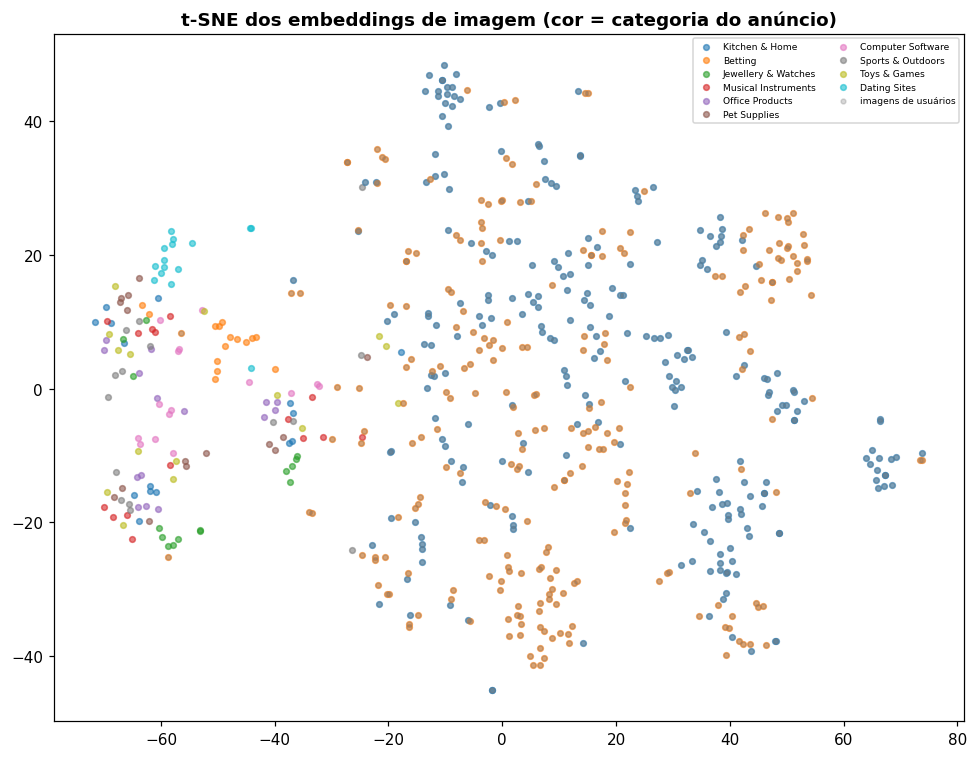

In [22]:
from sklearn.manifold import TSNE
# fig: tsne_embeddings
proj = TSNE(n_components=2, perplexity=10, init="pca", random_state=SEED).fit_transform(image_embeds.numpy())
fig, ax = plt.subplots(figsize=(9, 7))
is_ads = (corpus_df.source == "ads").to_numpy()
cats = corpus_df.category.fillna(corpus_df.pref).to_numpy()
for cat in pd.unique(cats):
    m = cats == cat
    ax.scatter(proj[m, 0], proj[m, 1], s=14, alpha=0.6, label=str(cat) if is_ads[m][0] else None)
ax.scatter(proj[~is_ads, 0], proj[~is_ads, 1], s=10, alpha=0.3, color="gray", label="imagens de usuários")
ax.legend(fontsize=6, ncol=2, loc="best")
ax.set_title("t-SNE dos embeddings de imagem (cor = categoria do anúncio)", fontweight="bold")
plt.tight_layout()
savefig("tsne_embeddings")
plt.show()

## 10. Métricas finais (JSON)

In [23]:
metrics = {
    "modelo": MODEL_NAME,
    "n_params_M": round(n_params / 1e6, 1),
    "logit_scale_exp": round(clip_model.logit_scale.exp().item(), 2),
    "corpus": {"total": len(corpus_df), "ads": len(ads_df), "usuarios": len(user_df),
               "n_usuarios": int(user_df.user.nunique())},
    "threshold": {"criterio": "margem sobre prompt neutro, percentil 90", "delta": float(DELTA)},
    "n_conceitos": len(CONCEPTS),
    "n_consultas": len(QUERIES),
    "tokenizacao": {"clip_max_len": 77, "diff_clip_padding": diff_clip,
                    "diff_bert_mask_maxabs": diff_bert.max().item()},
    "ram": ram_stats(),
    "vram_pico_mb": None if not torch.cuda.is_available() else round(torch.cuda.max_memory_allocated() / 2**20),
    "tempo_total_s": round(time.time() - NOTEBOOK_T0, 1),
    "versions": {"torch": torch.__version__},
    "seed": SEED,
}
(OUT_DIR / "A2_metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
print(json.dumps(metrics, indent=2, ensure_ascii=False))

{
  "modelo": "openai/clip-vit-base-patch32",
  "n_params_M": 151.3,
  "logit_scale_exp": 100.0,
  "corpus": {
    "total": 650,
    "ads": 150,
    "usuarios": 500,
    "n_usuarios": 60
  },
  "threshold": {
    "criterio": "margem sobre prompt neutro, percentil 90",
    "delta": 0.007230581250041723
  },
  "n_conceitos": 25,
  "n_consultas": 10,
  "tokenizacao": {
    "clip_max_len": 77,
    "diff_clip_padding": 1.4901161193847656e-07,
    "diff_bert_mask_maxabs": 5.424578666687012
  },
  "ram": {
    "ram_rss_mb": 2598,
    "ram_maxrss_mb": 2665
  },
  "vram_pico_mb": null,
  "tempo_total_s": 370.3,
  "versions": {
    "torch": "2.11.0+cpu"
  },
  "seed": 42
}
